**Exercício 2**

No codigo abaixo, procedemos com a implementação da função que gera um conjunto de bits de tamanho aleatório (entre 2 e 32), e repetimos tal como no exercício 1 a uma pesquisa aleatória, desta vez com o tamanho desconhecido, ou seja, podem ser gerados conjuntos com tamanho diferente do alvo, aumentando assim ligeiramente o tempo de busca em comparação ao exercicio 1. (foi imposto um limite de 1000 tentativas para não ter de percorrer conjuntos de 20+ bits que demoram mais tempo a ser encontrados)

Não Convergiu Teste 01: Tamanho alvo=29, Tentativas=100000, Tempo=0.334206s
Convergiu Teste 02: Tamanho alvo=6, Tentativas=1607, Tempo=0.006068s
Não Convergiu Teste 03: Tamanho alvo=32, Tentativas=100000, Tempo=0.336193s
Convergiu Teste 04: Tamanho alvo=9, Tentativas=35357, Tempo=0.119599s
Convergiu Teste 05: Tamanho alvo=9, Tentativas=48533, Tempo=0.162117s
Não Convergiu Teste 06: Tamanho alvo=21, Tentativas=100000, Tempo=0.334654s
Não Convergiu Teste 07: Tamanho alvo=27, Tentativas=100000, Tempo=0.335732s
Não Convergiu Teste 08: Tamanho alvo=12, Tentativas=100000, Tempo=0.338220s
Convergiu Teste 09: Tamanho alvo=9, Tentativas=1278, Tempo=0.004158s
Não Convergiu Teste 10: Tamanho alvo=16, Tentativas=100000, Tempo=0.339644s
Não Convergiu Teste 11: Tamanho alvo=20, Tentativas=100000, Tempo=0.337195s
Não Convergiu Teste 12: Tamanho alvo=16, Tentativas=100000, Tempo=0.336157s
Não Convergiu Teste 13: Tamanho alvo=17, Tentativas=100000, Tempo=0.334663s
Convergiu Teste 14: Tamanho alvo=10, T

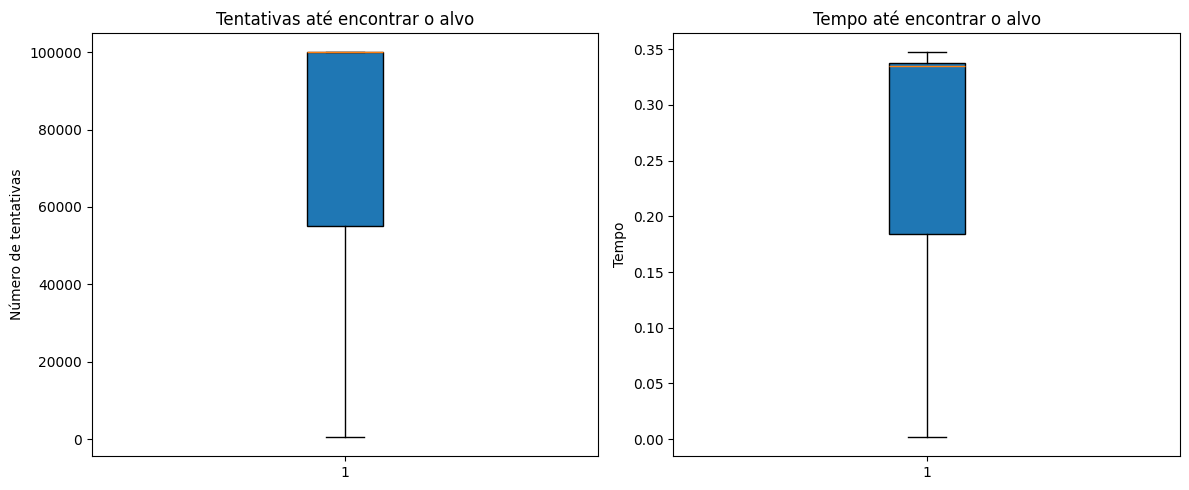


Tamanhos dos alvos: Média = 18.0 bits
Tentativas: Média = 75500, Mín = 564, Máx = 100000
Tempo médio: 0.2546s, Min = 0.0019s, Max = 0.3475s


In [1]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt

def gerar_padrao_aleatorio_tamanho_variavel(min_bits=2, max_bits=32, seed=None):
    if seed is not None:
        random.seed(seed)
    n_bits = random.randint(min_bits, max_bits)
    return [random.randint(0, 1) for _ in range(n_bits)]

def pesquisa_aleatoria_tamanho_variavel(n_repeticoes=30, max_tentativas=100000):
    tempos, tentativas, tamanhos_alvo = [], [], []
    
    for r in range(n_repeticoes):
        alvo = gerar_padrao_aleatorio_tamanho_variavel(seed=r)
        tamanho_alvo = len(alvo)
        tamanhos_alvo.append(tamanho_alvo)
        count = 0
        encontrou = False
        inicio = time.time()
        
        while not encontrou and count < max_tentativas:
            guess = gerar_padrao_aleatorio_tamanho_variavel()
            count += 1
            if guess == alvo:
                encontrou = True
        
        tempo_decorrido = time.time() - inicio
        tentativas.append(count)
        tempos.append(tempo_decorrido)
        status = "Convergiu" if encontrou else "Não Convergiu"
        print(f"{status} Teste {r+1:02d}: Tamanho alvo={tamanho_alvo}, Tentativas={count}, Tempo={tempo_decorrido:.6f}s")
    
    return tentativas, tempos, tamanhos_alvo

def experimento_aleatoria_boxplot_tamanho_variavel(n_repeticoes=30, max_tentativas=100000):
    tentativas, tempos, tamanhos = pesquisa_aleatoria_tamanho_variavel(n_repeticoes, max_tentativas)
    
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.boxplot(tentativas, patch_artist=True)
    plt.title("Tentativas até encontrar o alvo")
    plt.ylabel("Número de tentativas")
    
    plt.subplot(1,2,2)
    plt.boxplot(tempos, patch_artist=True)
    plt.title("Tempo até encontrar o alvo")
    plt.ylabel("Tempo")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTamanhos dos alvos: Média = {np.mean(tamanhos):.1f} bits")
    print(f"Tentativas: Média = {np.mean(tentativas):.0f}, Mín = {np.min(tentativas)}, Máx = {np.max(tentativas)}")
    print(f"Tempo médio: {np.mean(tempos):.4f}s, Min = {np.min(tempos):.4f}s, Max = {np.max(tempos):.4f}s")
    
    return tentativas, tempos, tamanhos

if __name__ == "__main__":
    tentativas, tempos, tamanhos = experimento_aleatoria_boxplot_tamanho_variavel(n_repeticoes=30)


O codigo seguinte cria a função que calcula o valor de fitness de uma entre um conjunto padrao e o conjunto alvo, uma função que pode inverter um bit aleatório de um conjunto em estudo, inserir um bit aleatório numa posição aleatória ou apagar um bit aleatório numa posição aleatória e por fim uma função do genero hill climbing, onde se gera uma solução aleatória que não é igual ao alvo, e esta é alterada(com a função de mutação referida anteriormente) com o intuito de melhorar o valor do fitness. Este processo acaba quando se encontra o alvo, ou seja, chega-se a um fitness=1 ou quando acontece mais de 1000 iterações e não se chegou a um valor de fitness=1. 

In [3]:
def fitness(padrao, alvo):
    len_p = len(padrao)
    len_a = len(alvo)
    min_len = min(len_p, len_a)
    
    erros = sum(1 for i in range(min_len) if padrao[i] != alvo[i])
    
    penalizacao_tamanho = abs(len_p - len_a)
    total_penalty = erros + penalizacao_tamanho
    
    tamanho_maximo = max(len_p, len_a, 1) 
    fitness_val = 1.0 - total_penalty / tamanho_maximo
    
    return max(0.0, fitness_val)


def mutar(padrao, min_bits=2, max_bits=32):
    novo = padrao.copy()
    len_atual = len(novo)
    
    pode_insert = len_atual < max_bits
    pode_delete = len_atual > min_bits
    
    if pode_insert and pode_delete:
        op = random.randint(0, 2) 
    elif pode_insert:
        op = random.randint(0, 1) 
    else:  
        op = 0 if random.randint(0, 1) == 0 else 2  
    
    if op == 0:  
        idx = random.randint(0, len_atual - 1)
        novo[idx] = 1 - novo[idx]
    elif op == 1:  
        bit = random.randint(0, 1)
        pos = random.randint(0, len_atual)
        novo.insert(pos, bit)
    else: 
        idx = random.randint(0, len_atual - 1)
        del novo[idx]
    
    return novo
    

def melhorar_por_mutacao(alvo, max_mutacoes=1000, seed=None):
    if seed is not None:
        random.seed(seed)
    atual = gerar_padrao_aleatorio_tamanho_variavel(seed) 
    melhor_fit = fitness(atual, alvo)
    
    for i in range(max_mutacoes):
        padrao = mutar(atual)
        fit_cand = fitness(padrao, alvo)
        if fit_cand > melhor_fit:
            atual = padrao
            melhor_fit = fit_cand
        if atual == alvo:
            print(f"Convergiu em {i+1} mutações (tamanho={len(atual)} bits)")
            return True, i + 1
    
    print(f"Não convergiu após {max_mutacoes} mutações (melhor fitness={melhor_fit:.3f})")
    return False, max_mutacoes


def testar_convergencia_mutacao_tamanho_variavel(n_testes=30, max_mutacoes=1000):
    resultados = []
    tamanhos = []

    for r in range(n_testes):
        alvo = gerar_padrao_aleatorio_tamanho_variavel(seed=r)
        convergiu, iteracoes = melhorar_por_mutacao(alvo, max_mutacoes=max_mutacoes, seed=r)
        resultados.append((convergiu, iteracoes))
        tamanhos.append(len(alvo))
        
        print(f"Teste {r+1:02d}: Alvo={len(alvo):2d} bits, iterações={iteracoes}")

    convergiu_total = sum(c for c, _ in resultados)
    media_iter = np.mean([it for _, it in resultados])
    taxa = convergiu_total / n_testes * 100

    print(f"\nConvergiu: {convergiu_total}/{n_testes} ({taxa:.1f}%)")
    print(f"Média de iterações: {media_iter:.1f}")


    return resultados, tamanhos

if __name__ == "__main__":
    resultados, tamanhos = testar_convergencia_mutacao_tamanho_variavel(n_testes=30, max_mutacoes=1000)



Convergiu em 114 mutações (tamanho=29 bits)
Teste 01: Alvo=29 bits, iterações=114
Convergiu em 18 mutações (tamanho=6 bits)
Teste 02: Alvo= 6 bits, iterações=18
Convergiu em 1 mutações (tamanho=32 bits)
Teste 03: Alvo=32 bits, iterações=1
Convergiu em 23 mutações (tamanho=9 bits)
Teste 04: Alvo= 9 bits, iterações=23
Convergiu em 126 mutações (tamanho=9 bits)
Teste 05: Alvo= 9 bits, iterações=126
Convergiu em 73 mutações (tamanho=21 bits)
Teste 06: Alvo=21 bits, iterações=73
Convergiu em 33 mutações (tamanho=27 bits)
Teste 07: Alvo=27 bits, iterações=33
Convergiu em 96 mutações (tamanho=12 bits)
Teste 08: Alvo=12 bits, iterações=96
Convergiu em 85 mutações (tamanho=9 bits)
Teste 09: Alvo= 9 bits, iterações=85
Convergiu em 74 mutações (tamanho=16 bits)
Teste 10: Alvo=16 bits, iterações=74
Convergiu em 147 mutações (tamanho=20 bits)
Teste 11: Alvo=20 bits, iterações=147
Convergiu em 164 mutações (tamanho=16 bits)
Teste 12: Alvo=16 bits, iterações=164
Convergiu em 170 mutações (tamanho=17 

Tal como no exercicio 1, noo codigo seguinte procedemos com execução do algoritmo evolutivo básico para encontrar um padrão bínario igual ao alvo. Assim, começamos por gerar uma população de 100 padrões (mas desta vez cada padrãp pode/tem tamanhos diferentes) e avaliamos o fitness de cada um. Posteriormente, os 30 melhores padrões são mantido e usados para gerar filhos por mutação(inserir ou deletar ou mutar bits), criando assim uma nova população. É importante dizer que o processo repete-se até a evolução estagnar(ou seja, se não melhorar o fitness nas ultimas 50 gerações) ou se o fitness chegar a 1.

Convergiu na geração 32
Convergiu Teste 01: Alvo=29 bits, gerações=32, tempo=0.005s
Convergiu na geração 5
Convergiu Teste 02: Alvo=6 bits, gerações=5, tempo=0.001s
Convergiu na geração 41
Convergiu Teste 03: Alvo=32 bits, gerações=41, tempo=0.007s
Convergiu na geração 8
Convergiu Teste 04: Alvo=9 bits, gerações=8, tempo=0.001s
Convergiu na geração 8
Convergiu Teste 05: Alvo=9 bits, gerações=8, tempo=0.001s
Convergiu na geração 21
Convergiu Teste 06: Alvo=21 bits, gerações=21, tempo=0.003s
Convergiu na geração 30
Convergiu Teste 07: Alvo=27 bits, gerações=30, tempo=0.004s
Convergiu na geração 13
Convergiu Teste 08: Alvo=12 bits, gerações=13, tempo=0.002s
Convergiu na geração 8
Convergiu Teste 09: Alvo=9 bits, gerações=8, tempo=0.001s
Convergiu na geração 19
Convergiu Teste 10: Alvo=16 bits, gerações=19, tempo=0.003s
Convergiu na geração 18
Convergiu Teste 11: Alvo=20 bits, gerações=18, tempo=0.003s
Convergiu na geração 11
Convergiu Teste 12: Alvo=16 bits, gerações=11, tempo=0.002s
Conv

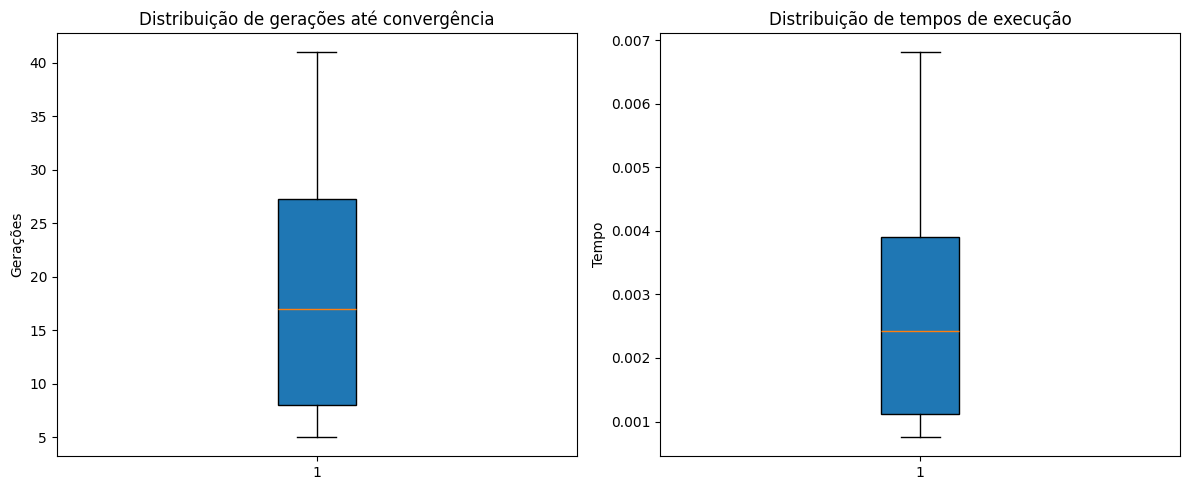

In [78]:
def algoritmo_evolutivo_tamanho_variavel(alvo, pop_size=100, taxa_selecao=0.3, max_geracoes=1000):
    populacao = [gerar_padrao_aleatorio_tamanho_variavel() for _ in range(pop_size)]
    historico_melhor = []
    melhor_fitness = -1
    geracao = 0

    while geracao < max_geracoes:
        geracao += 1
        fit_values = [fitness(ind, alvo) for ind in populacao]
        idx_melhor = np.argmax(fit_values)
        fit_atual = fit_values[idx_melhor]
        historico_melhor.append(fit_atual)

        if populacao[idx_melhor] == alvo:
            print(f"Convergiu na geração {geracao}")
            return populacao[idx_melhor], geracao, True, historico_melhor


        n_selecionados = int(pop_size * taxa_selecao)
        idx_ordenados = np.argsort(fit_values)[::-1]
        melhores = [populacao[i] for i in idx_ordenados[:n_selecionados]]

        nova_pop = melhores.copy()
        while len(nova_pop) < pop_size:
            pai = random.choice(melhores)
            filho = mutar(pai)
            nova_pop.append(filho)

        populacao = nova_pop

    
    print(f"Não convergiu após {geracao} gerações (melhor fitness={melhor_fitness:.3f})")
    return populacao[idx_melhor], geracao, False, historico_melhor

def testar_algoritmo_evolutivo_tamanho_variavel(n_testes=30, pop_size=100, max_geracoes=1000):
    resultados = []
    tempos = []
    
    for r in range(n_testes):
        alvo = gerar_padrao_aleatorio_tamanho_variavel(seed=r)
        inicio = time.time()
        melhor, geracoes, convergiu, hist = algoritmo_evolutivo_tamanho_variavel(
            alvo, pop_size=pop_size, max_geracoes=max_geracoes)
        tempo_decorrido = time.time() - inicio
        resultados.append((convergiu, geracoes))
        tempos.append(tempo_decorrido)
        status = "Convergiu" if convergiu else "Não convergiu"
        print(f"{status} Teste {r+1:02d}: Alvo={len(alvo)} bits, gerações={geracoes}, tempo={tempo_decorrido:.3f}s")

    n_convergiu = sum(c for c, _ in resultados)
    media_geracoes = np.mean([g for _, g in resultados])
    media_tempo = np.mean(tempos)

    print(f"\nConvergiu: {n_convergiu}/{n_testes} ({n_convergiu/n_testes*100:.1f}%)")
    print(f"Média de gerações: {media_geracoes:.1f}")
    print(f"Média de tempo: {media_tempo:.3f}s")

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.boxplot([g for _, g in resultados], vert=True, patch_artist=True)
    plt.title("Distribuição de gerações até convergência")
    plt.ylabel("Gerações")

    plt.subplot(1,2,2)
    plt.boxplot(tempos, vert=True, patch_artist=True)
    plt.title("Distribuição de tempos de execução")
    plt.ylabel("Tempo")

    plt.tight_layout()
    plt.show()

    return resultados, tempos

if __name__ == "__main__":
    resultados, tempos = testar_algoritmo_evolutivo_tamanho_variavel(n_testes=30, pop_size=100, max_geracoes=1000)

No codigo seguinte procedemos com a execução do algoritmo evolutivo com cruzamento para encontrar um padrão bínario igual ao alvo. Assim, começamos por gerar uma população de 100 padrões e avaliamos o fitness de cada um. Posteriormente, os 30 melhores padrões são mantidos e usados para gerar filhos por cruzamento entre pais (isto com o uso da função de cruzamento criada com o intuito de miturar dois conjuntos diferentes). Depois disso existe a chance do filho criado sofrer mutação, sendo acrescentado de seguida (mesmo não levando mutação) á nova população. O procedimento de adicionar novos filhos repete-se até ser formada novamente uma população de 100 padrões.

Convergiu na geração 94
Convergiu Teste 01: Alvo=29 bits, gerações=94, tempo=0.019s
Convergiu na geração 5
Convergiu Teste 02: Alvo=6 bits, gerações=5, tempo=0.001s
Convergiu na geração 61
Convergiu Teste 03: Alvo=32 bits, gerações=61, tempo=0.012s
Convergiu na geração 8
Convergiu Teste 04: Alvo=9 bits, gerações=8, tempo=0.002s
Convergiu na geração 8
Convergiu Teste 05: Alvo=9 bits, gerações=8, tempo=0.001s
Convergiu na geração 23
Convergiu Teste 06: Alvo=21 bits, gerações=23, tempo=0.004s
Convergiu na geração 84
Convergiu Teste 07: Alvo=27 bits, gerações=84, tempo=0.016s
Convergiu na geração 14
Convergiu Teste 08: Alvo=12 bits, gerações=14, tempo=0.002s
Convergiu na geração 2
Convergiu Teste 09: Alvo=9 bits, gerações=2, tempo=0.001s
Convergiu na geração 24
Convergiu Teste 10: Alvo=16 bits, gerações=24, tempo=0.004s
Convergiu na geração 22
Convergiu Teste 11: Alvo=20 bits, gerações=22, tempo=0.004s
Convergiu na geração 32
Convergiu Teste 12: Alvo=16 bits, gerações=32, tempo=0.005s
Conv

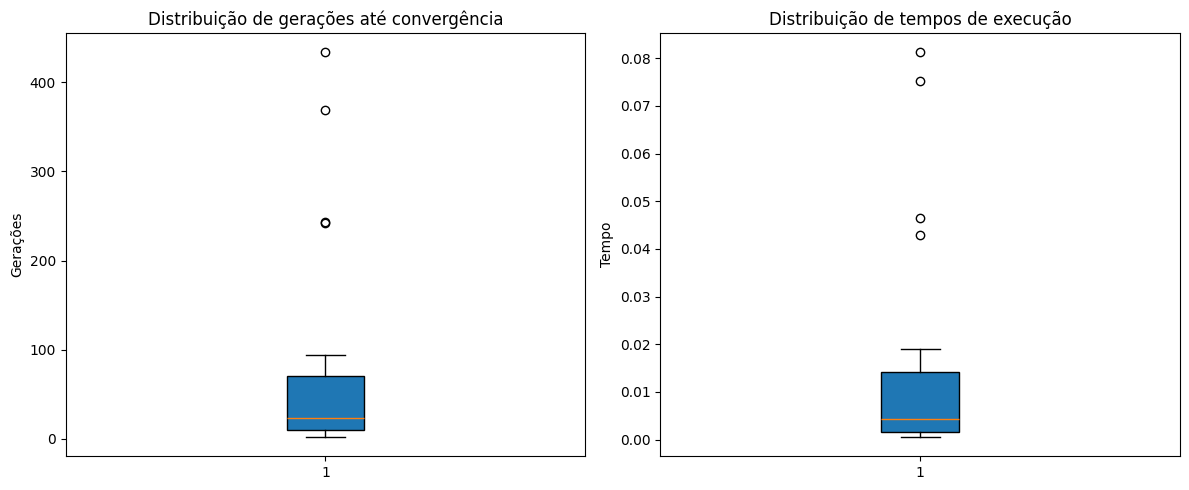

In [ ]:
def cruzamento(pai1, pai2, min_bits=2, max_bits=32):
    ponto1 = random.randint(0, len(pai1))
    ponto2 = random.randint(0, len(pai2))
    
    filho = pai1[:ponto1] + pai2[ponto2:]
    
    if len(filho) < min_bits:
        bits_falta = min_bits - len(filho)
        bits_extra = [random.randint(0, 1) for _ in range(bits_falta)]
        filho.extend(bits_extra)
    elif len(filho) > max_bits:
        filho = filho[:max_bits]
    
    return filho

def algoritmo_genetico_tamanho_variavel(alvo, pop_size=100, taxa_selecao=0.3, max_geracoes=1000, prob_mut=0.1):
    populacao = [gerar_padrao_aleatorio_tamanho_variavel() for _ in range(pop_size)]
    historico_melhor = []
    melhor_fitness = -1
    geracao = 0

    while geracao < max_geracoes :
        geracao += 1
        fit_values = [fitness(ind, alvo) for ind in populacao]
        idx_melhor = np.argmax(fit_values)
        fit_atual = fit_values[idx_melhor]
        historico_melhor.append(fit_atual)

        if populacao[idx_melhor] == alvo:
            print(f"Convergiu na geração {geracao}")
            return populacao[idx_melhor], geracao, True, historico_melhor


        n_selecionados = int(pop_size * taxa_selecao)
        idx_ordenados = np.argsort(fit_values)[::-1]
        melhores = [populacao[i] for i in idx_ordenados[:n_selecionados]]

        nova_pop = melhores.copy()
        while len(nova_pop) < pop_size:
            pai1, pai2 = random.sample(melhores, 2)
            filho = cruzamento(pai1, pai2)

            if random.random() < prob_mut:
                filho = mutar(filho)
            nova_pop.append(filho)

        populacao = nova_pop

    print(f"Não convergiu após {geracao} gerações (melhor fitness={melhor_fitness:.3f})")
    return populacao[idx_melhor], geracao, False, historico_melhor

def testar_algoritmo_genetico_tamanho_variavel(n_testes=30, pop_size=100, max_geracoes=1000):
    resultados = []
    tempos = []

    for r in range(n_testes):
        alvo = gerar_padrao_aleatorio_tamanho_variavel(seed=r)
        inicio = time.time()
        melhor, geracoes, convergiu, hist = algoritmo_genetico_tamanho_variavel(
            alvo, pop_size=pop_size, max_geracoes=max_geracoes)
        tempo_decorrido = time.time() - inicio
        resultados.append((convergiu, geracoes))
        tempos.append(tempo_decorrido)
        status = "Convergiu" if convergiu else "Não convergiu"
        print(f"{status} Teste {r+1:02d}: Alvo={len(alvo)} bits, gerações={geracoes}, tempo={tempo_decorrido:.3f}s")

    n_convergiu = sum(c for c, _ in resultados)
    media_geracoes = np.mean([g for _, g in resultados])
    media_tempo = np.mean(tempos)

    print(f"\nConvergiu: {n_convergiu}/{n_testes} ({n_convergiu/n_testes*100:.1f}%)")
    print(f"Média de gerações: {media_geracoes:.1f}")
    print(f"Média de tempo: {media_tempo:.3f}s")

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.boxplot([g for _, g in resultados], vert=True, patch_artist=True)
    plt.title("Distribuição de gerações até convergência")
    plt.ylabel("Gerações")

    plt.subplot(1,2,2)
    plt.boxplot(tempos, vert=True, patch_artist=True)
    plt.title("Distribuição de tempos de execução")
    plt.ylabel("Tempo")

    plt.tight_layout()
    plt.show()

    return resultados, tempos

if __name__ == "__main__":
    resultados, tempos = testar_algoritmo_genetico_tamanho_variavel(n_testes=30, pop_size=100, max_geracoes=1000)

Neste exercicio 2, foi possivel perceber que as diferenças em relação ao exercicío 1 nas funções implementadas foram as seguintes:

- Primeiramente a função para gerar um padrão ja não é com tamanho escolhido mas sim tamanho variado entre 2 e 32.
- A função de avaliação (fitness), em vez de lidar com padrões do mesmo tamanho está preparada para lidar com padrões de tamanhos diferentes, avaliando quantos elementos coincidem nos índices correspondentes e adicionando uma penalização proporcional à diferença de tamanho entre eles.
- A funcão mutar neste caso altera um padrão de bits de forma aleatória, podendo inverter um bit, inserir um novo bit ou remover um bit, respeitando também os limites mínimos e máximos de comprimento.
- A função cruzamento combina dois padrões de bits de tamanhos possivelmente diferente, cortando cada pai em pontos aleatórios e unindo os segmentos para formar um filho. Esta função garante que o comprimento do filho fique dentro dos limites mínimos e máximos, preenchendo ou apagando bits quando necessário.